In [1]:
from nilearn.glm.first_level import make_first_level_design_matrix

import matplotlib.pyplot as plt
import nibabel as nib
import nilearn as ni
import pandas as pd
import numpy as np
from nilearn.glm.first_level import FirstLevelModel

In [2]:
subj = "sub-05"
path = "./fMRI_HW/Data/preprocessed"

t1 = nib.load(f"{path}/{subj}_desc-brain.nii.gz")
# mean_img = nib.Nifti1Image(t1.get_fdata(), t1.affine, header=t1.header)

fmri1_loc = nib.load(
    f"{path}/{subj}_task-rest_run-2_space-T1w_desc-preproc_bold.nii.gz"
)

In [3]:
# Get data shapes
t1_data = t1.get_fdata()
bold_data = fmri1_loc.get_fdata()
print("T1w shape:", t1_data.shape)
print("BOLD shape:", bold_data.shape)

T1w shape: (176, 256, 256)
BOLD shape: (78, 92, 74, 250)


In [4]:
# I got this code from AI to be able to see task info
def print_header_info(img, name=""):
    data = img.get_fdata()
    zooms = img.header.get_zooms()
    
    print(f"\n{'='*50}")
    print(f"Header Info: {name}")
    print(f"{'='*50}")
    print(f"Shape:          {data.shape}")
    print(f"Voxel sizes:    X: {zooms[0]:.3f}mm, Y: {zooms[1]:.3f}mm, Z: {zooms[2]:.3f}mm")
    
    if len(data.shape) == 4:
        tr = zooms[3]
        print(f"TR:             {tr:.3f} seconds")
        print(f"Total time:     {data.shape[3] * tr:.1f} seconds ({data.shape[3] * tr / 60:.2f} min)")
    
    print(f"Data type:      {img.get_data_dtype()}")
    print(f"Memory:         {data.nbytes / (1024*1024):.1f} MB")
    print(f"Value range:    {data.min():.2f} to {data.max():.2f}")
    print(f"Orientation:    {nib.aff2axcodes(img.affine)}")
    print(f"{'='*50}\n")

# Use it:
print_header_info(t1, "T1 Structural")
print_header_info(fmri1_loc, "fMRI BOLD")


Header Info: T1 Structural
Shape:          (176, 256, 256)
Voxel sizes:    X: 1.000mm, Y: 0.996mm, Z: 0.996mm
Data type:      float32
Memory:         88.0 MB
Value range:    0.00 to 1433.08
Orientation:    ('R', 'A', 'S')


Header Info: fMRI BOLD
Shape:          (78, 92, 74, 250)
Voxel sizes:    X: 1.836mm, Y: 1.836mm, Z: 1.890mm
TR:             2.500 seconds
Total time:     625.0 seconds (10.42 min)
Data type:      int16
Memory:         1012.8 MB
Value range:    -132.23 to 2454.04
Orientation:    ('R', 'A', 'S')



# General Linear Model
### Event Matrix generation

In [5]:
# Parameters
TR = 2.5  # Repetition time in seconds
num_volumes = fmri1_loc.shape[-1]  # 250 volumes in the main run
block_duration = 25  # Block duration in seconds
task_start_time = 32  # Task starts 32 seconds into the main run
total_time = num_volumes * TR  # Total fMRI scan time
task_end_time = total_time - 7 * TR  # final 7 volumes are baseline

# Create one event per block; time outside these events is baseline.
events = []
modes = ["mode_1", "mode_2", "mode_3"]
current_time = task_start_time
mode_index = 0

while current_time + block_duration <= task_end_time:
    duration = block_duration
    events.append(
        {"onset": current_time, "duration": duration, "trial_type": modes[mode_index]}
    )

    mode_index = (mode_index + 1) % len(modes)
    current_time += duration

events_matrix = pd.DataFrame(events)
events_matrix

,onset,duration,trial_type
0,32,25,mode_1
1,57,25,mode_2
2,82,25,mode_3
3,107,25,mode_1
4,132,25,mode_2
5,157,25,mode_3
6,182,25,mode_1
7,207,25,mode_2
8,232,25,mode_3
9,257,25,mode_1


## Design matrix

In [6]:
tr = 2.5  # repetition time is 2.5 second

# drift model is there because bold signal jumps from 1 to 2 and 2 to 1
# but the actual signal is a continious one and drift model picture that
# (make a slope instead of jump)

# hrf model is there to show the relation between neural activity and bold signal
drift_model = "cosine"
hrf_model = "glover + derivative + dispersion"
dsgn_mx1 = make_first_level_design_matrix(
    np.arange(fmri1_loc.shape[-1]) * tr,
    drift_model=drift_model,
    events=events_matrix,
    hrf_model=hrf_model,
)

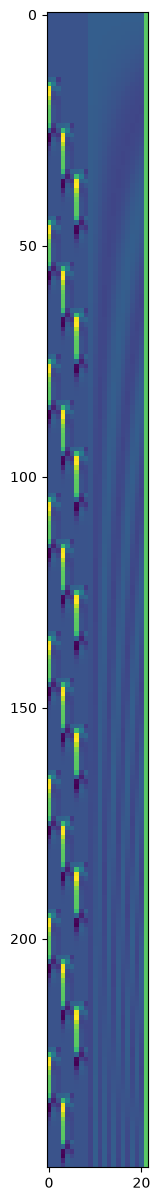

In [7]:
plt.figure(figsize=(20, 15))
plt.imshow(dsgn_mx1)

## Drop confounders + fit GLM

In [8]:
confound_vars = [
    "csf",
    "white_matter",
    "global_signal",
    "framewise_displacement",
    "t_comp_cor_00",
    "t_comp_cor_01",
    "t_comp_cor_02",
    "trans_x",
    "trans_y",
    "trans_z",
    "rot_x",
    "rot_y",
    "rot_z",
]

In [9]:
confounds_path = f"{path}/{subj}_task-rest_run-2_desc-confounds_timeseries.tsv"
confounds_df = pd.read_csv(confounds_path, sep="\t")

confounds_df.bfill(inplace=True)

selected_confounds = confounds_df[confound_vars]

assert selected_confounds.shape[0] == fmri1_loc.shape[-1]

fmri_glm_with_cof = FirstLevelModel(
    smoothing_fwhm=5,
    t_r=TR,
    minimize_memory=False,
    drift_model=drift_model,
    hrf_model=hrf_model,
)
fmri_glm_with_cof = fmri_glm_with_cof.fit(
    fmri1_loc,
    events=events_matrix,
    confounds=selected_confounds,
)


In [10]:
contrasts = {
    "mode_1_vs_2": "mode_1 - mode_2",
    "mode_2_vs_3": "mode_2 - mode_3",
    "mode_1_vs_3": "mode_1 - mode_3",
}

contrast_imgs = {}
for name, contrast in contrasts.items():
    contrast_imgs[name] = fmri_glm_with_cof.compute_contrast(
        contrast, output_type="z_score"
    )
    nib.save(contrast_imgs[name], f"{path}/{subj}_{name}_z_score.nii.gz")

mode_1_vs_2_img = contrast_imgs["mode_1_vs_2"]
mode_2_vs_3_img = contrast_imgs["mode_2_vs_3"]
mode_1_vs_3_img = contrast_imgs["mode_1_vs_3"]

## Visulaization the Z-score result

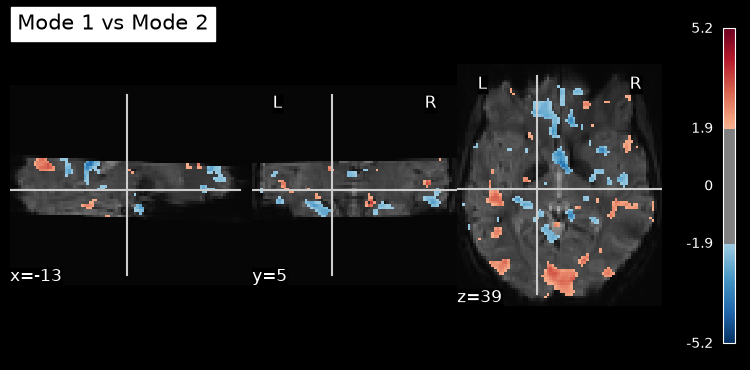

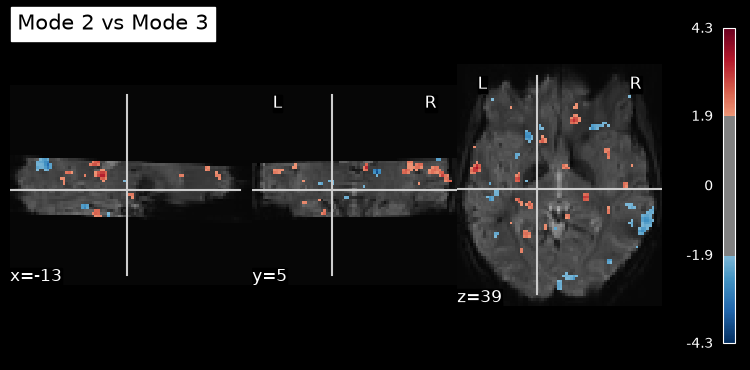

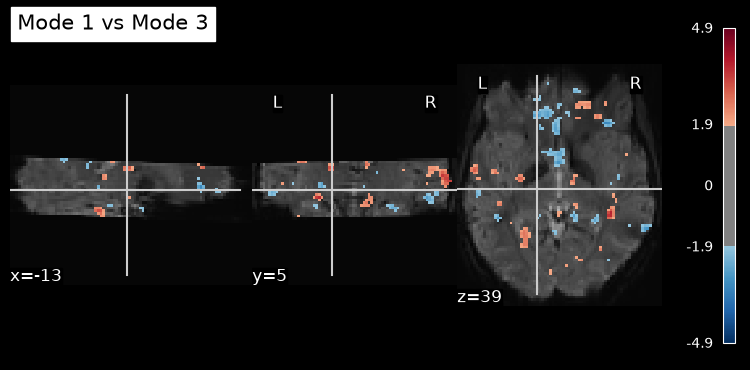

In [11]:
from nilearn import plotting

mean_img = nib.Nifti1Image(
    bold_data.mean(axis=3),
    fmri1_loc.affine,
    fmri1_loc.header,
)

plotting.plot_stat_map(
    mode_1_vs_2_img,
    bg_img=mean_img,
    cut_coords=(-13.21, 5.51, 39.30),
    threshold=1.9,
    title="Mode 1 vs Mode 2",
)
plotting.plot_stat_map(
    mode_2_vs_3_img,
    bg_img=mean_img,
    cut_coords=(-13.21, 5.51, 39.30),
    threshold=1.9,
    title="Mode 2 vs Mode 3",
)
plotting.plot_stat_map(
    mode_1_vs_3_img,
    bg_img=mean_img,
    cut_coords=(-13.21, 5.51, 39.30),
    threshold=1.9,
    title="Mode 1 vs Mode 3",
)